# Bandstructure

The band structure is demonstrated with Energy (in eV) versus K-point distance (in Å^2)


In [1]:
#### Bandstructure (Graphene)

"""
# Plot bandstructure for a list of matters with customize style 
def plot_bandstructure

# Plot bandstructure for a list of matters and DoS with customize style 
def plot_bandstructure_DoS

# Plot bandstructure for a list of matters and two DoS frames with customize style 
def plot_bandstructure_duoDoS

# Plot bandstructure for a list of matters and PDoS with customize style 
def plot_bandstructure_PDoS

# Plot bandstructure for a list of matters and two PDoS frames of with customize style 
def_plot_bandstructure_duoPDoS
"""

import matplotlib.pyplot as plt

from vmatplot.bandstructure import *
from vmatplot.output import canvas_setting, color_sampling

def plot_bandstructure(title, eigen_range=None, plot_type=None, matters_list=None, legend_loc="False"):
    # Help information
    help_info = "Usage: plot_bandstructure" + \
                "arg[0]: title;\n" + \
                "arg[1]: the range of eigenvalues, from -arg[1] to arg[1];\n" + \
                "arg[2]: plotting type: 'monocolor', 'fermi', 'orbit';\n" + \
                "arg[3]: matters list.\n"
    if title in ["help", "Help"]:
        print(help_info)

    # Figure settings
    fig_setting = canvas_setting()
    plt.figure(figsize=fig_setting[0], dpi = fig_setting[1])
    params = fig_setting[2]; plt.rcParams.update(params)
    plt.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)

    # Colors calling
    fermi_color = color_sampling("Orange")
    annotate_color = color_sampling("Grey")

    # Bandstructure data calling
    matters = create_matters_bs(matters_list)
    # matters = create_matters_bs(matters_list)
    # matters[0] = label
    # matters[1] = fermi_energy
    # matters[2] = kpoints path: x-axis
    # matters[3] = bands
    # matters[4] = color family

    if plot_type == "monocolor":
        for matter in matters:
            for bands_index in range(0, len(matter[3])):
                fermi = matter[1]
                current_band = [eigenvalue - fermi for eigenvalue in matter[3][bands_index]]
                # plt.plot(matter[2], current_band, c=color_sampling(matter[4])[1], label=f"Bandstructure for {matter[0]}", zorder=4)
                if bands_index == 0:
                    plt.plot(matter[2], current_band, c=color_sampling(matter[4])[1], label=f"Bandstructure for {matter[0]}", zorder=4)
                else:
                    plt.plot(matter[2], current_band, c=color_sampling(matter[4])[1], zorder=4)

    # Plotting range
    plt.ylim(eigen_range*(-1), eigen_range)
    plt.xlim(matter[2][0], matter[2][-1])

    # Fermi energy as a horizon line
    plt.axhline(y = 0, color=fermi_color[1], alpha=0.95, linestyle="--", label="Fermi energy", zorder=2)

    # Title
    plt.title(f"Bandstructure for {title}")
    plt.ylabel("Shifted energy (eV)")
    # plt.ylabel("$E-E_\text{F}$ (eV)")

    # x-axis ticks
    high_symmetry_paths = kpoints_path(matters_list[-1][1])
    high_symmetry_positions = list(high_symmetry_paths.values())
    high_symmetry_positions.append(matter[2][-1])
    high_symmetry_labels = list(high_symmetry_paths.keys())
    high_symmetry_labels.append(high_symmetry_labels[0])
    plt.xticks(high_symmetry_positions, high_symmetry_labels)
    for k_loc in high_symmetry_positions[1:-1]:
        plt.axvline(x=k_loc, color=annotate_color[1], linestyle="--", zorder=1)

    # Legends
    if legend_loc == None:
        legend = plt.legend()
        legend.set_visible(False)
    else:
        plt.legend(loc=legend_loc)


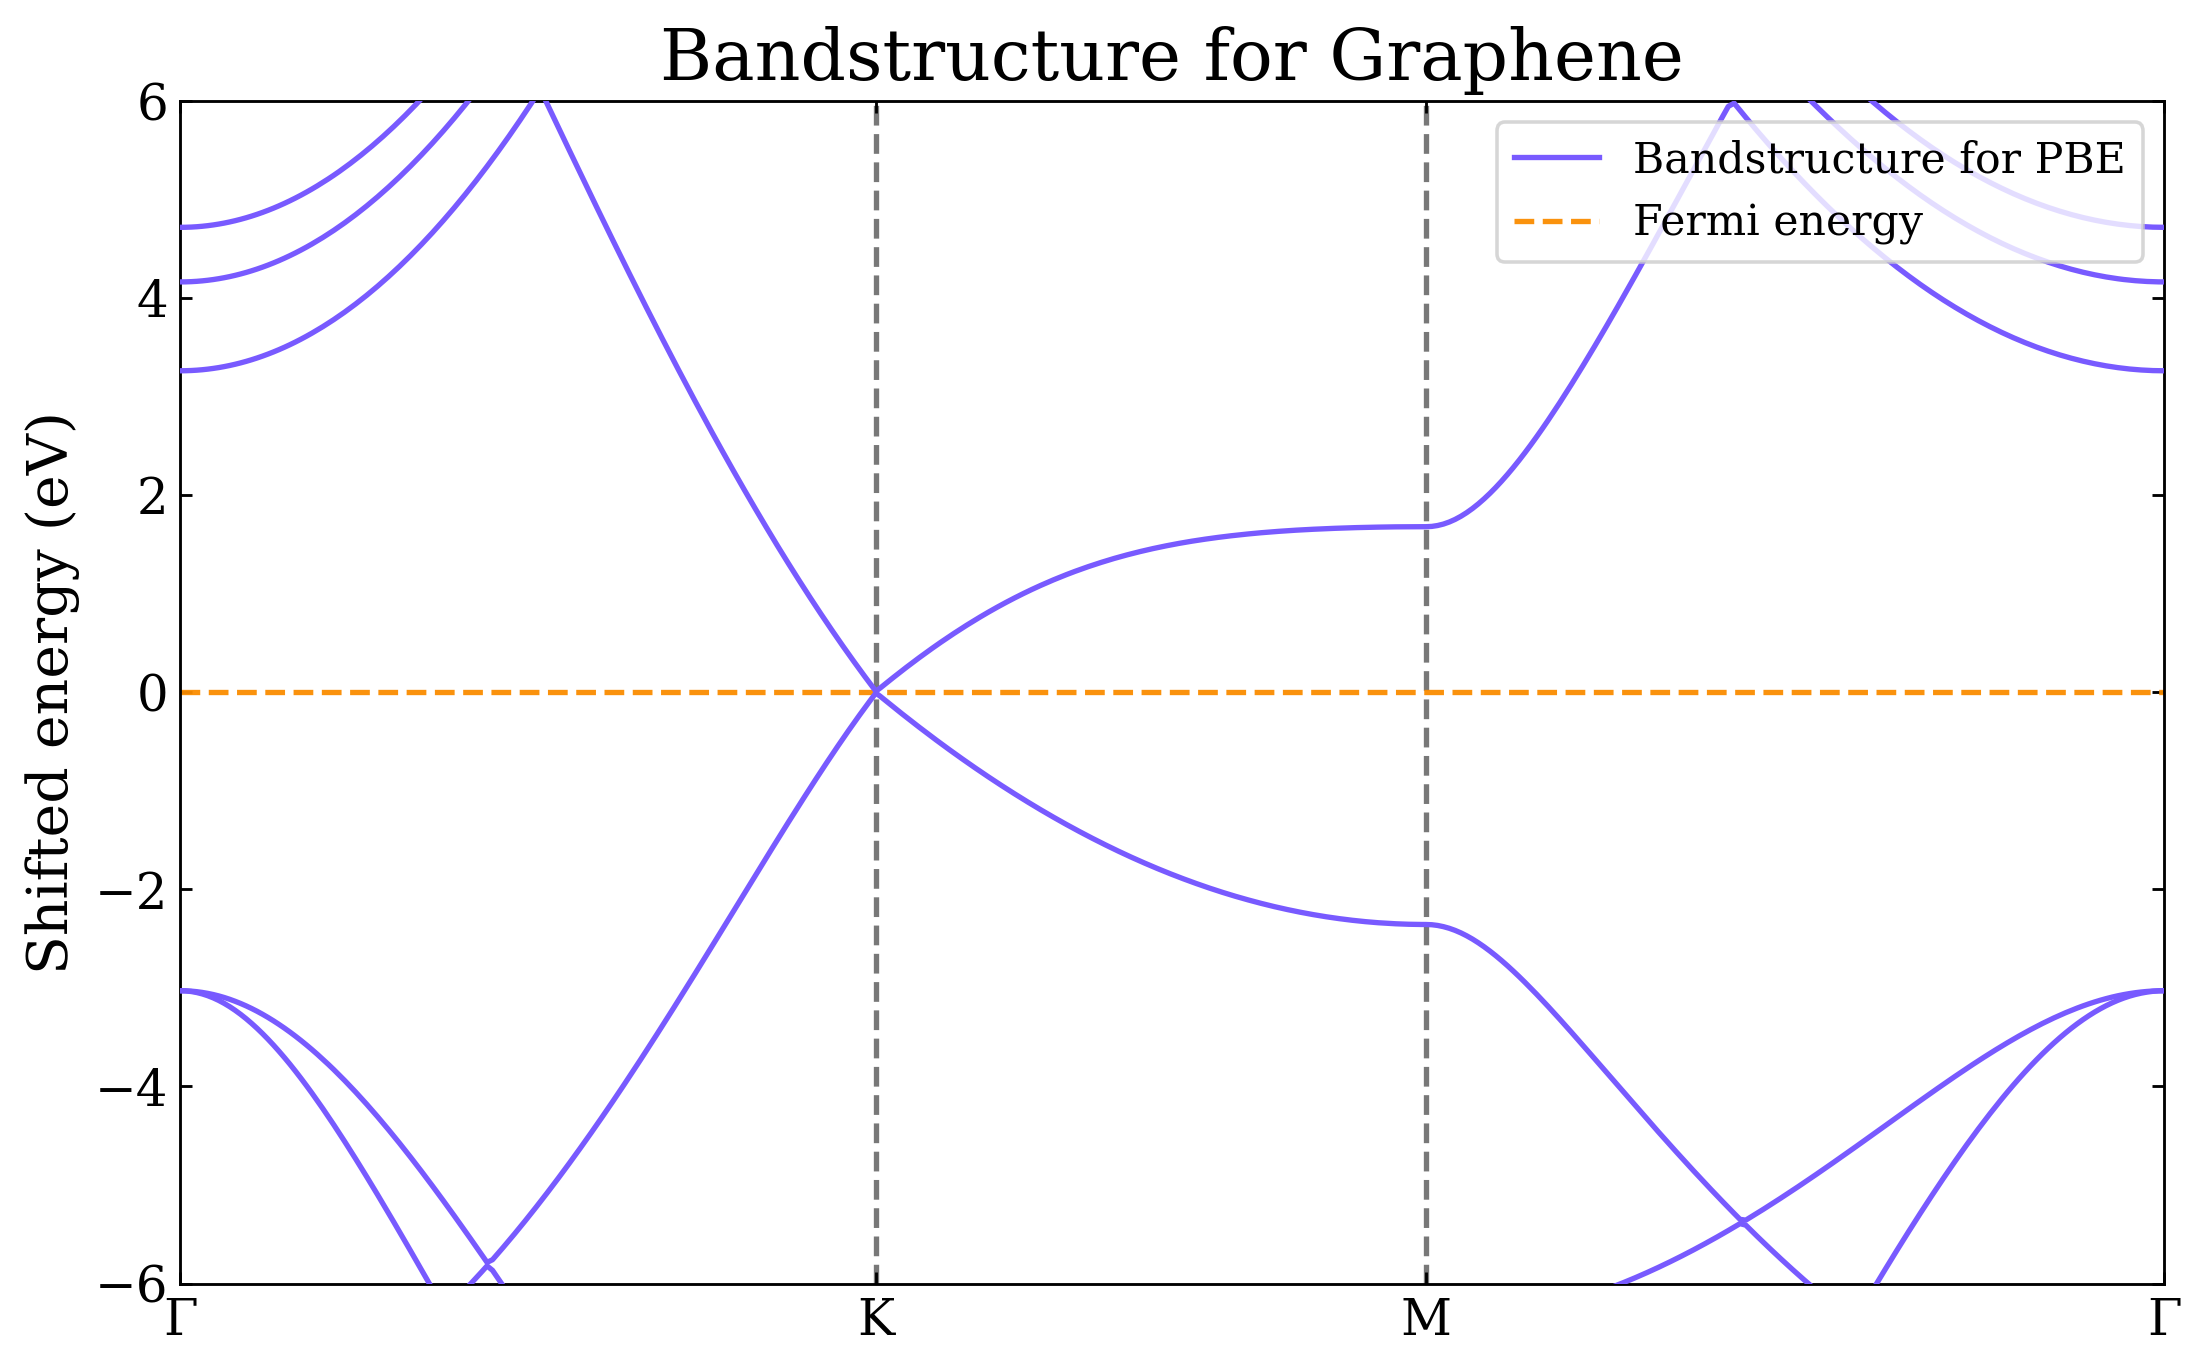

In [2]:
# Graphene

bandstructure_list = [["PBE","3_Bandstructure_PBE/D_Graphene","cold"]]
# bandstructure_list = [["HSE06","3_Bandstructure_HSE06/D_Graphene","cold"]]
# bandstructure_list = [["PBE","3_Bandstructure_PBE/D_Graphene","warm"], ["HSE06","3_Bandstructure_HSE06/D_Graphene","cold"]]

pdos_list = [["PBE", "4_PDoS_PBE/D_Graphene_K129", "warm"]]

plot_bandstructure("Graphene", 6, "monocolor", bandstructure_list, "upper right")


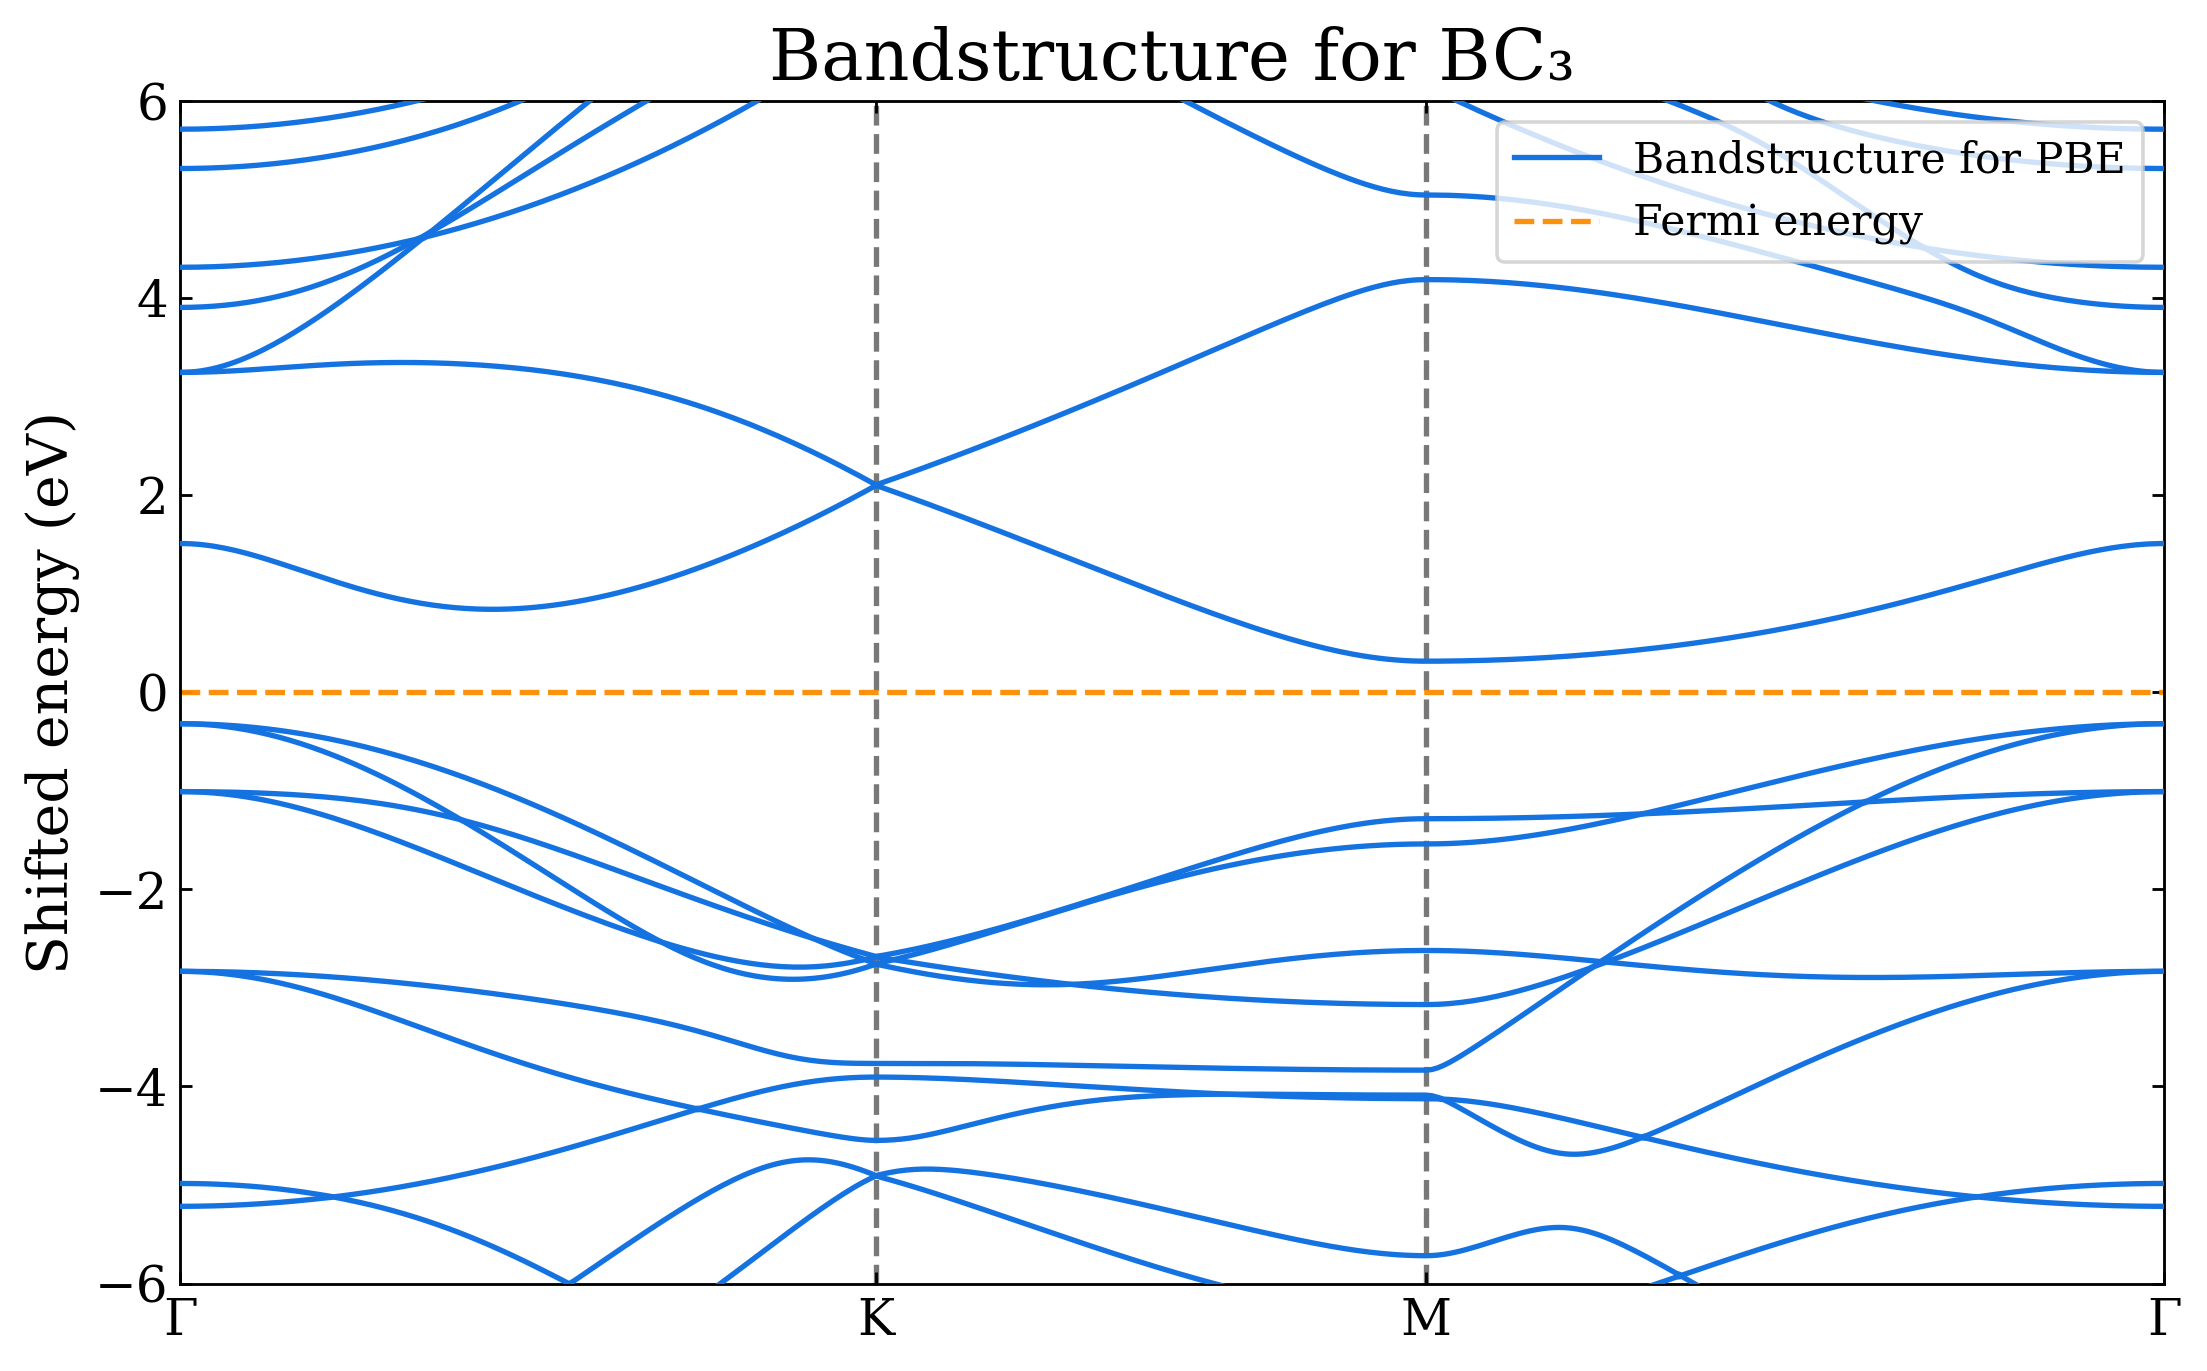

In [3]:
# BC₃

bandstructure_list = [["PBE","3_Bandstructure_PBE/A_BC3","blue"]]

plot_bandstructure("BC₃", 6, "monocolor", bandstructure_list, "upper right")


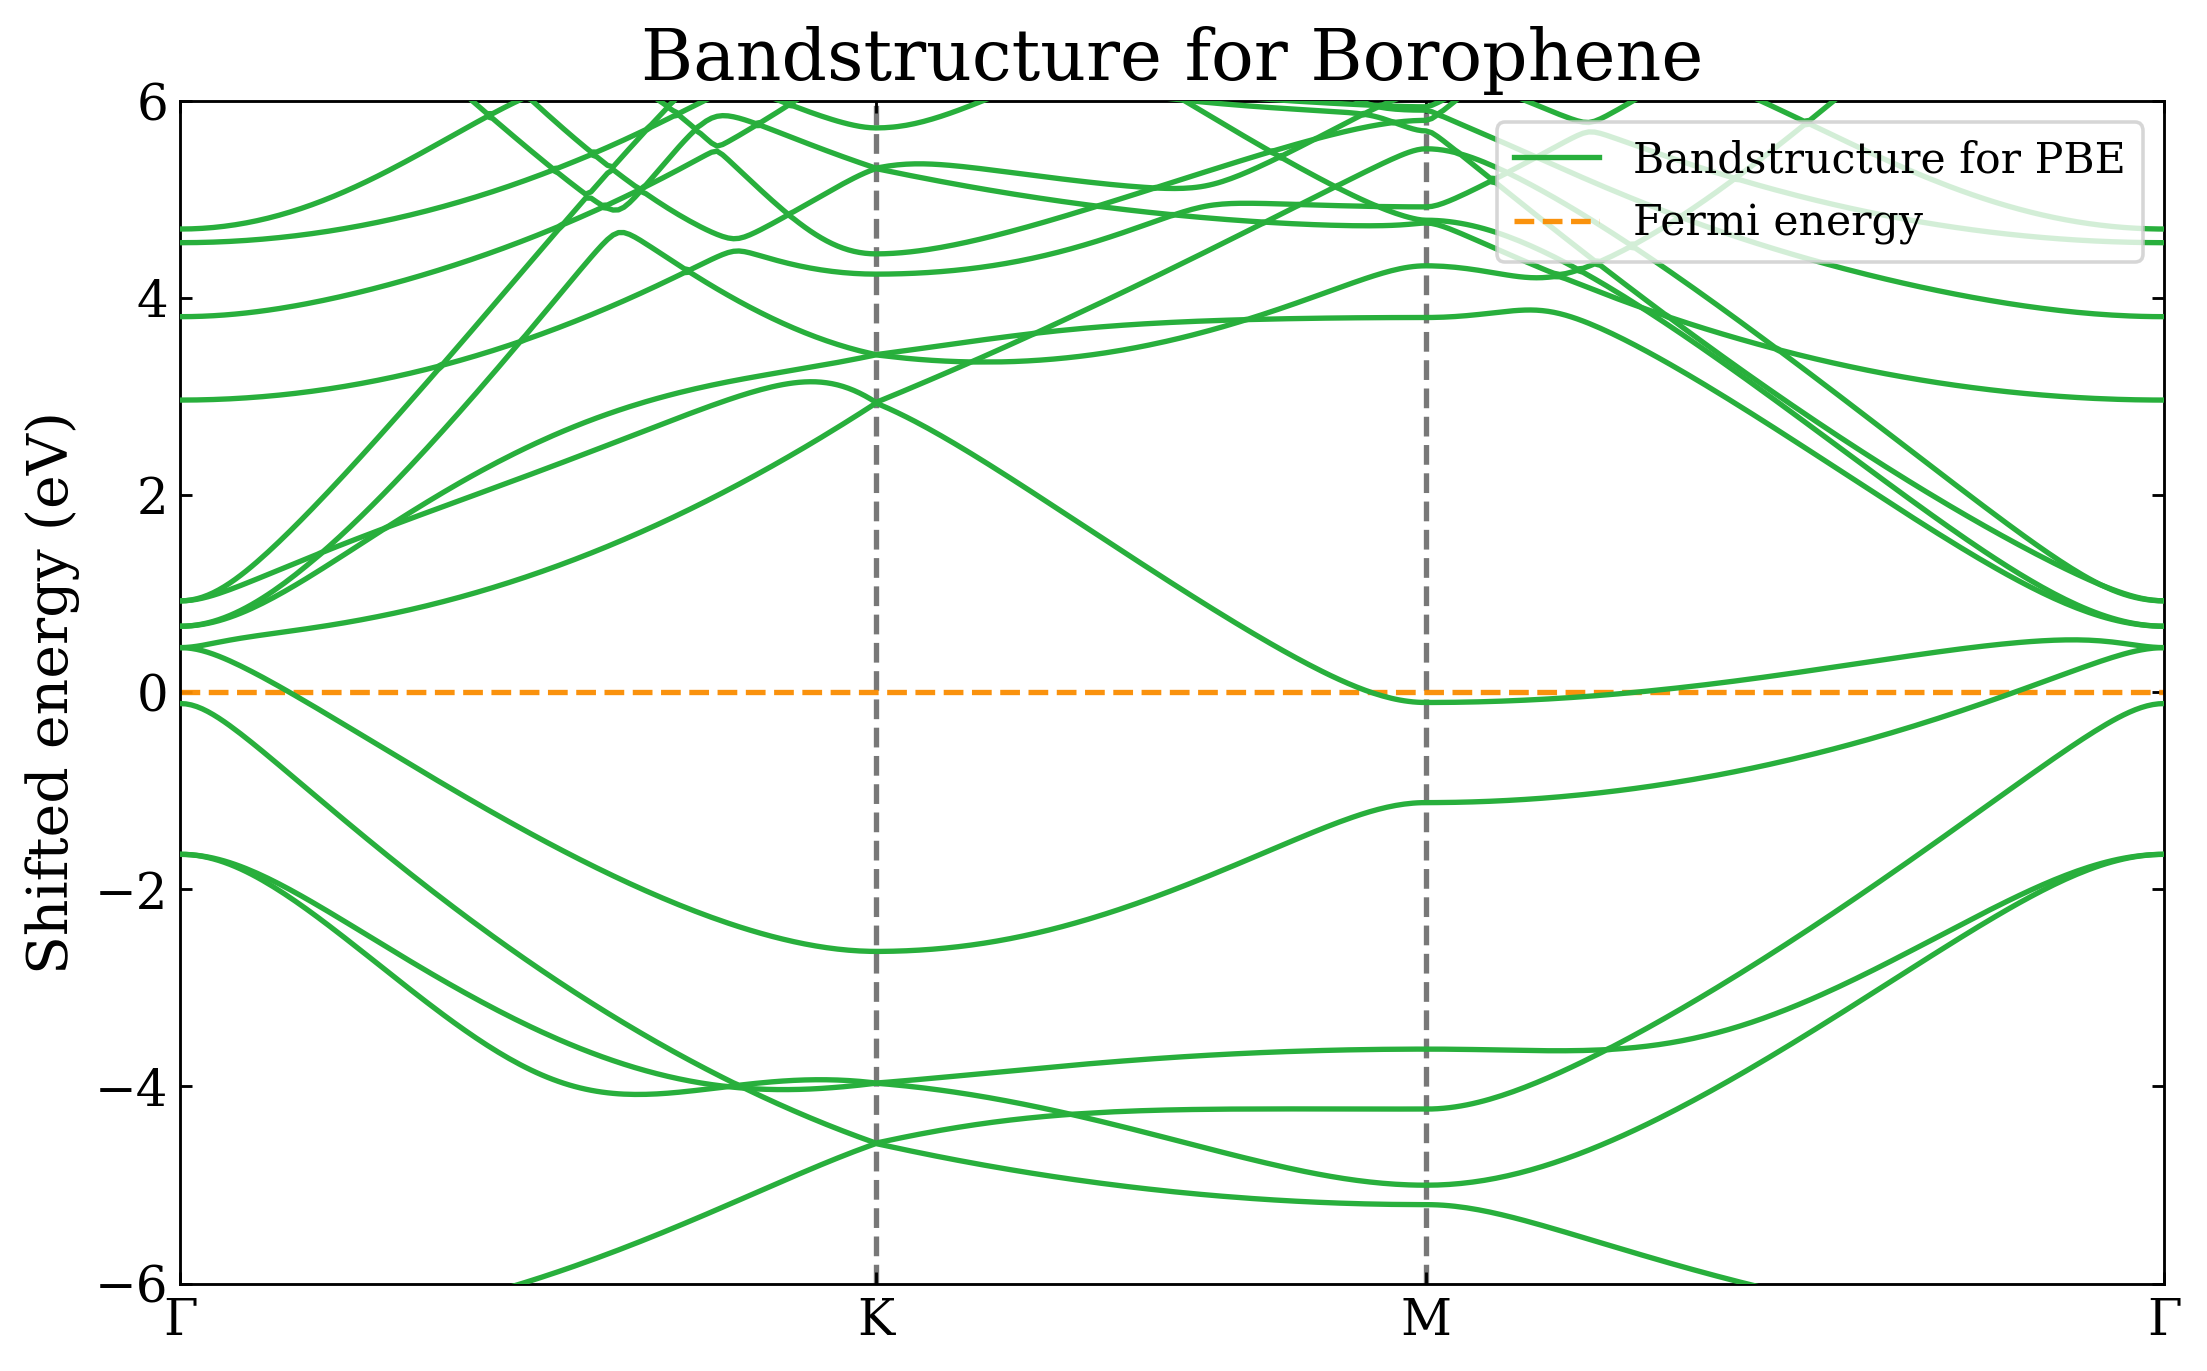

In [4]:
# Borophene

bandstructure_list = [["PBE","3_Bandstructure_PBE/B_Borophene","green"]]

plot_bandstructure("Borophene", 6, "monocolor", bandstructure_list, "upper right")


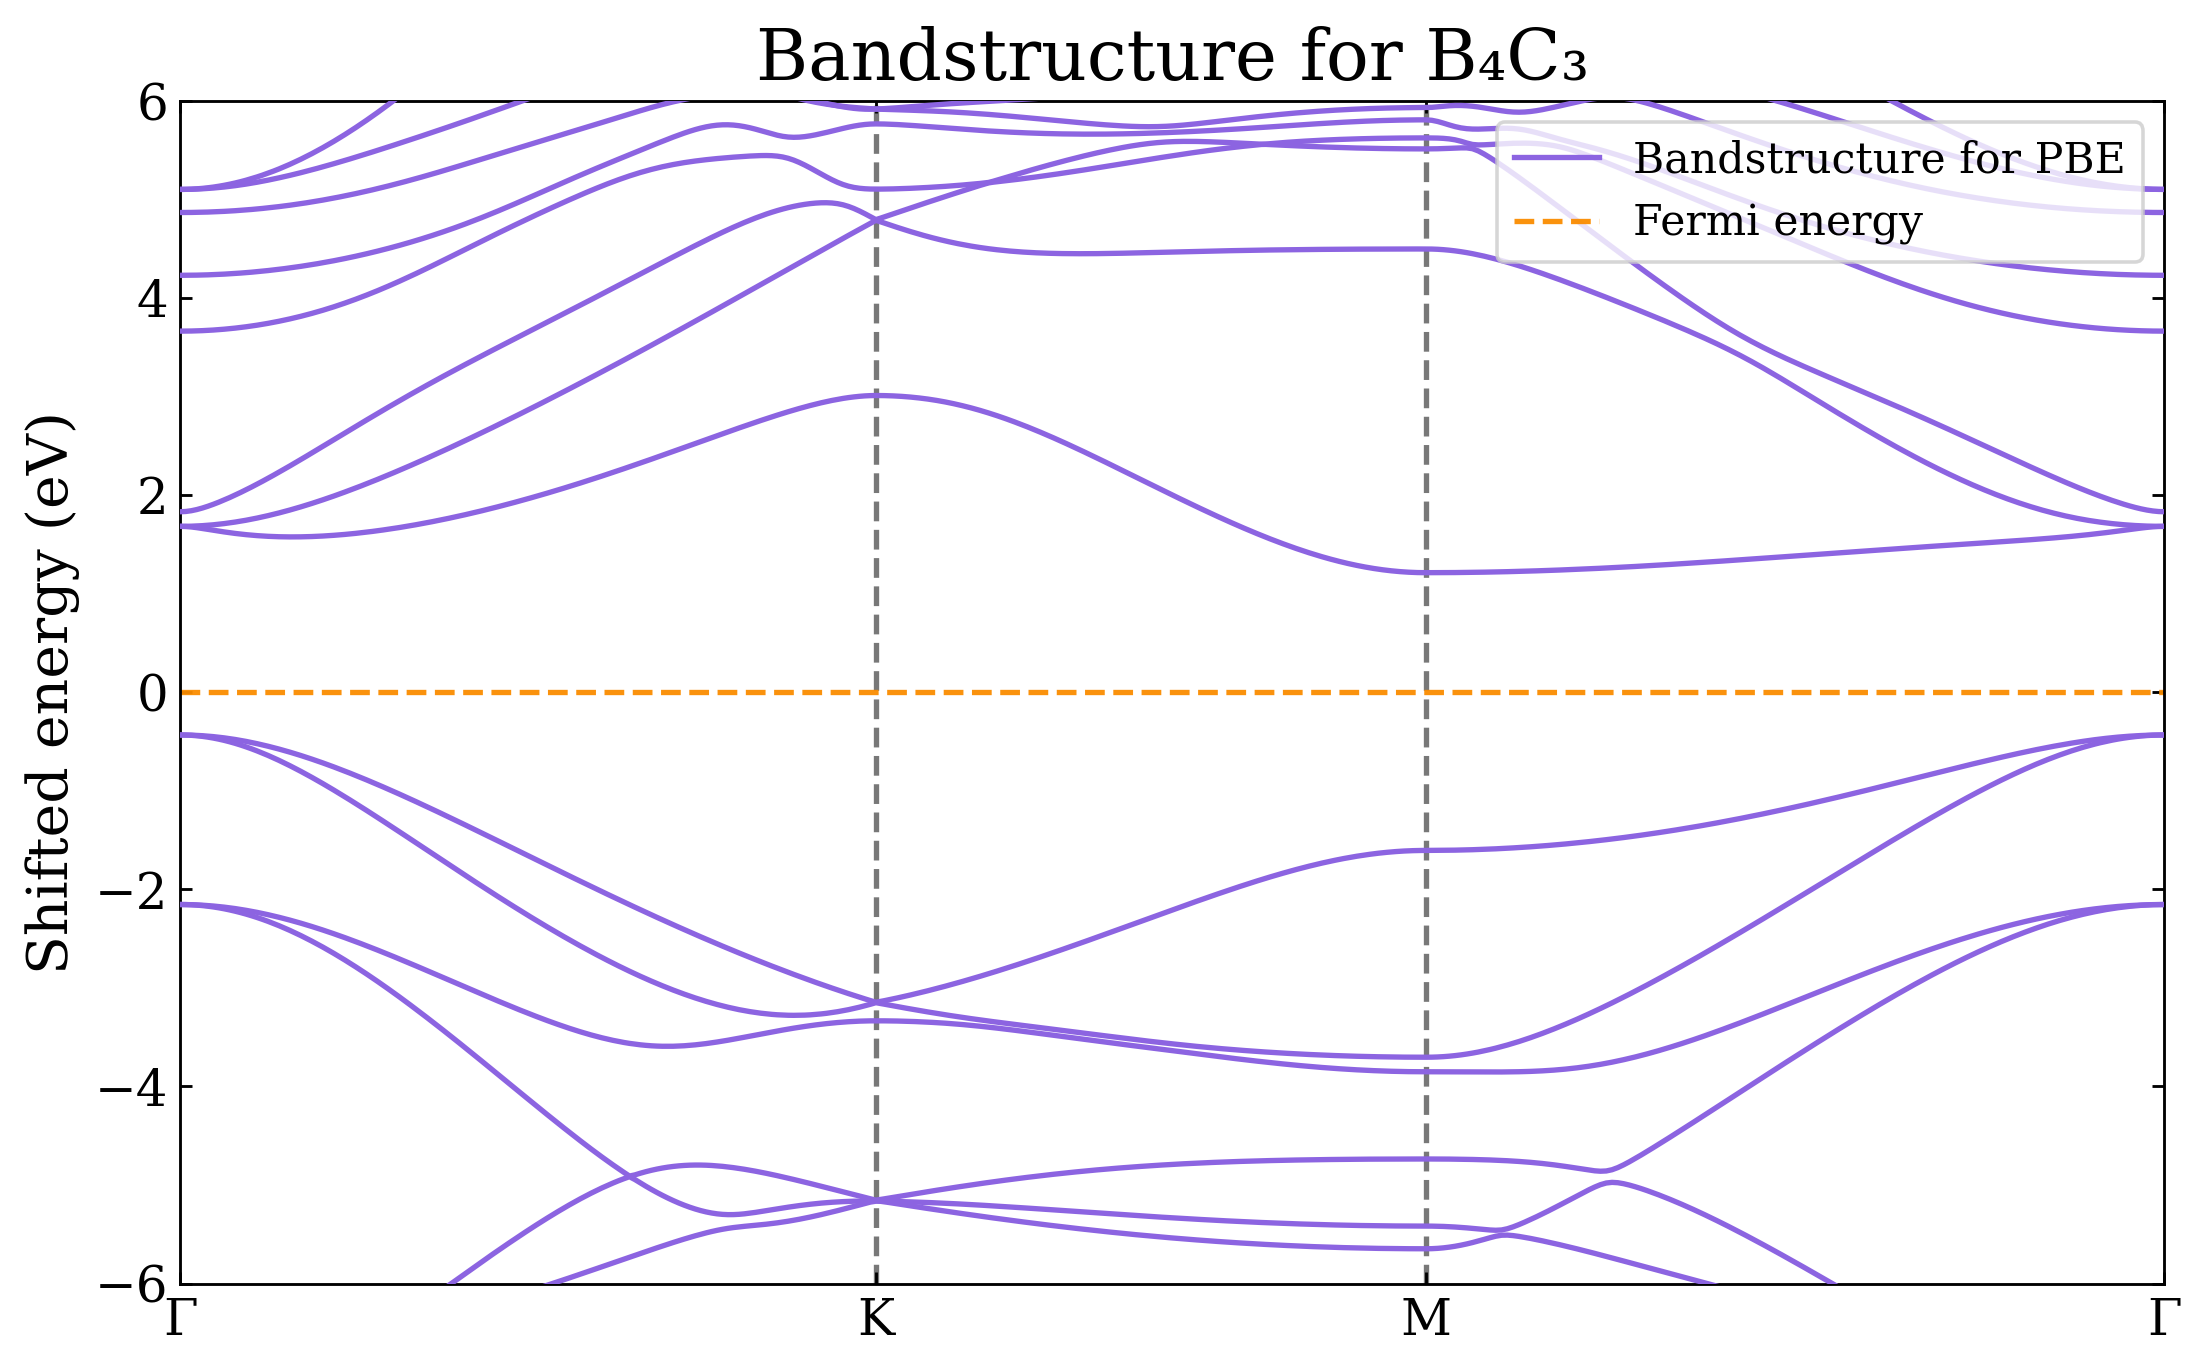

In [5]:
# B₄C₃

bandstructure_list = [["PBE","3_Bandstructure_PBE/C_B4C3","violet"]]

plot_bandstructure("B₄C₃", 6, "monocolor", bandstructure_list, "upper right")


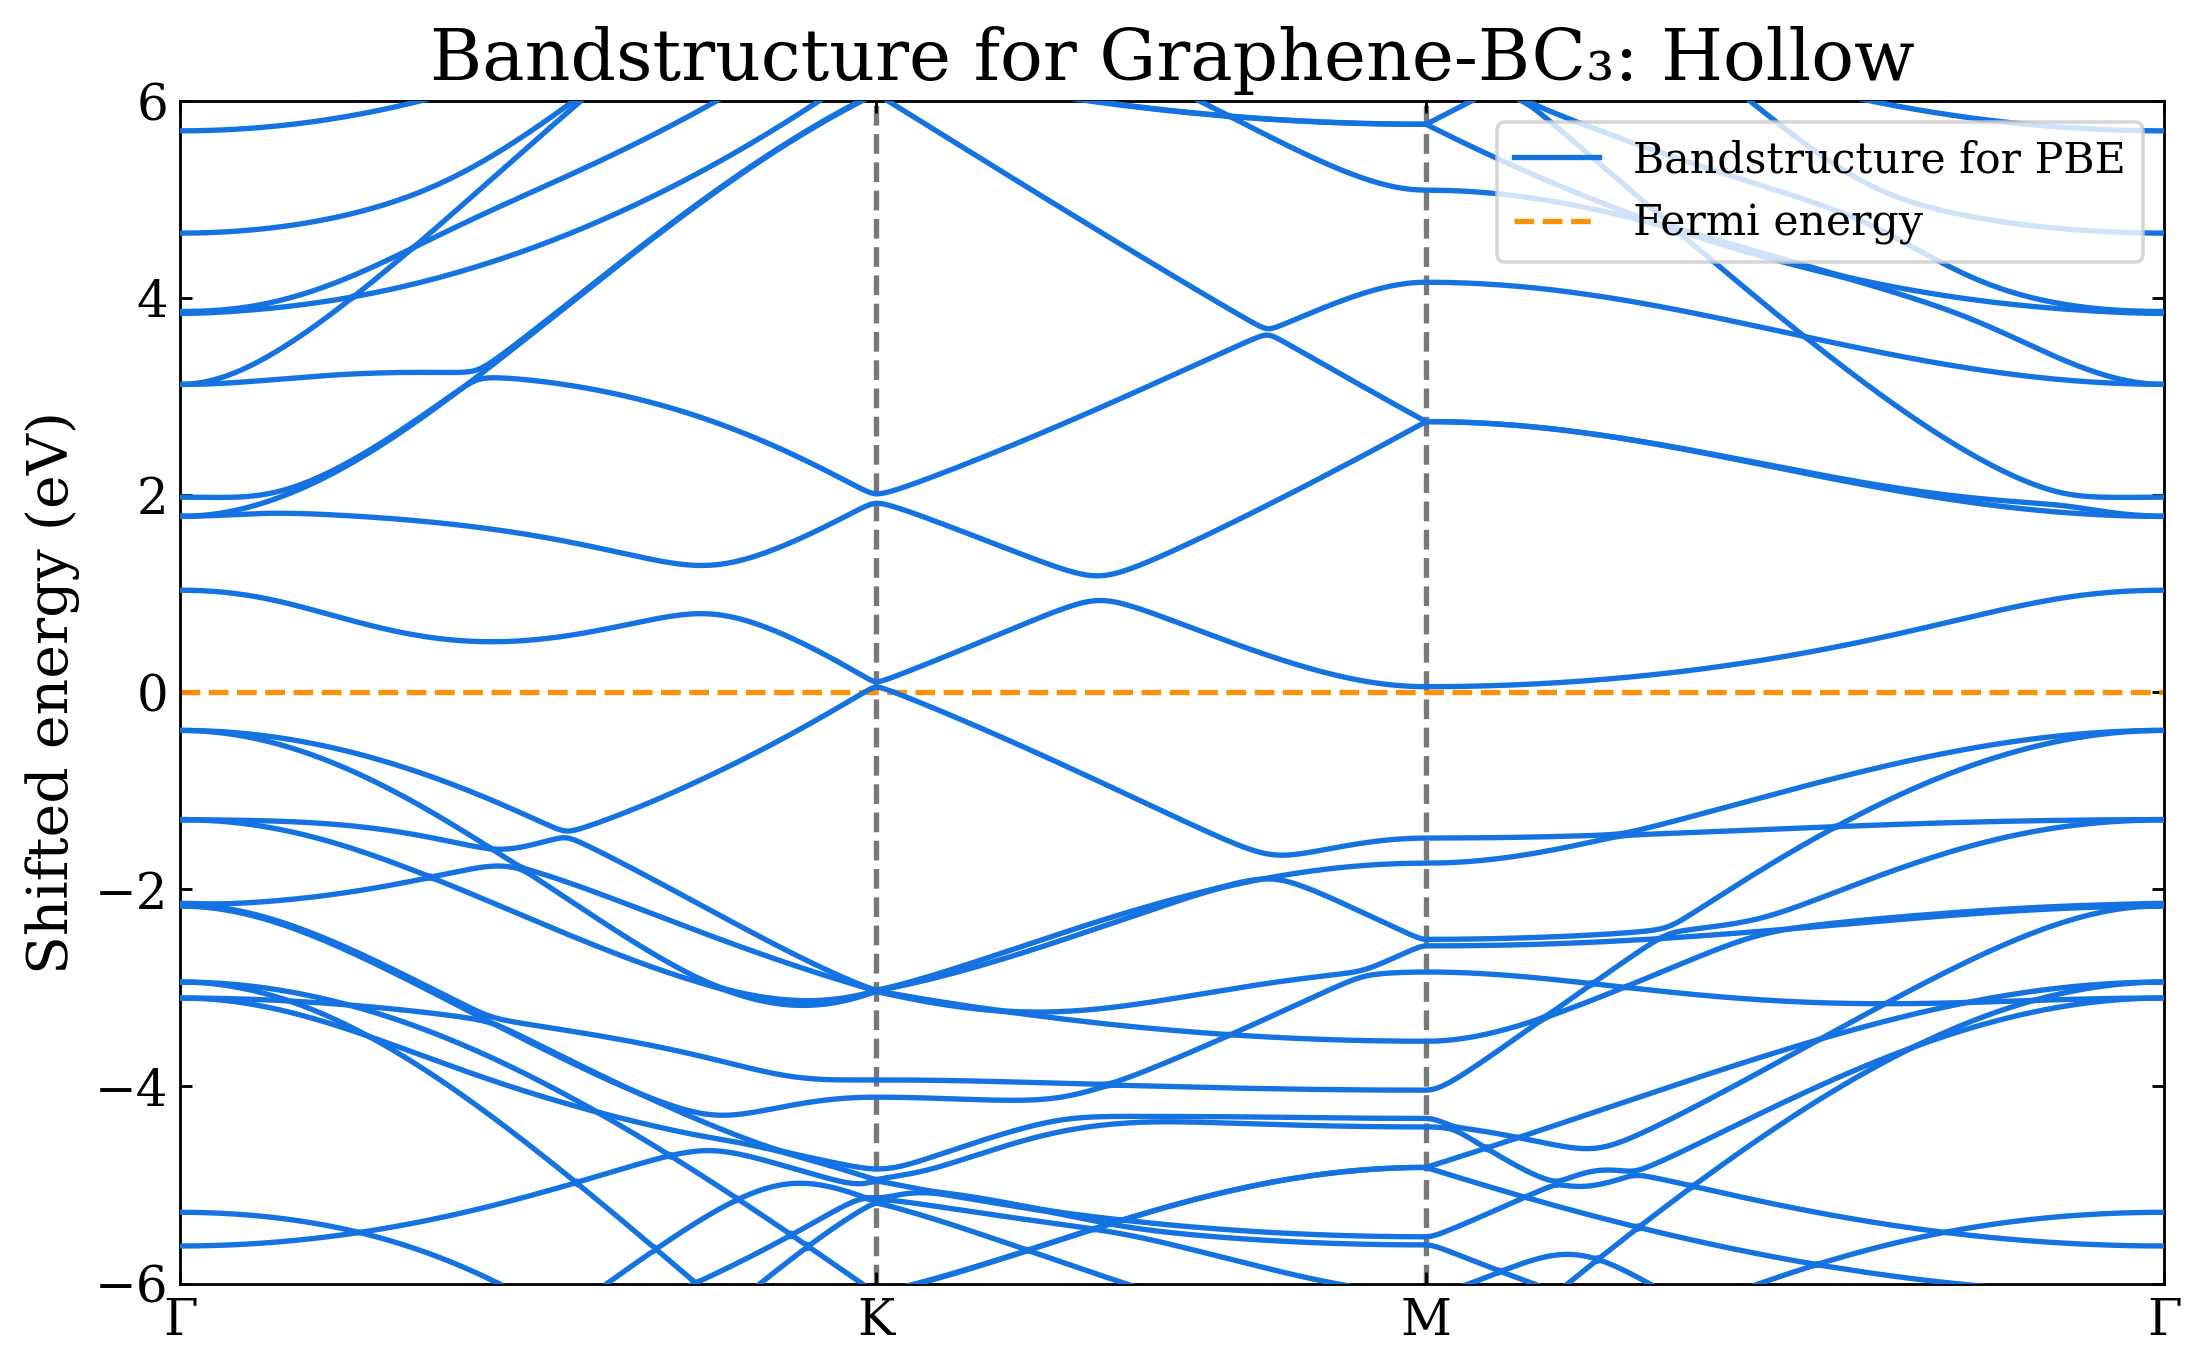

In [6]:
# Graphene-BC₃: Hollow

bandstructure_list = [["PBE","3_Bandstructure_PBE/E_Graphene-BC3_Hollow","blue"]]

plot_bandstructure("Graphene-BC₃: Hollow", 6, "monocolor", bandstructure_list, "upper right")


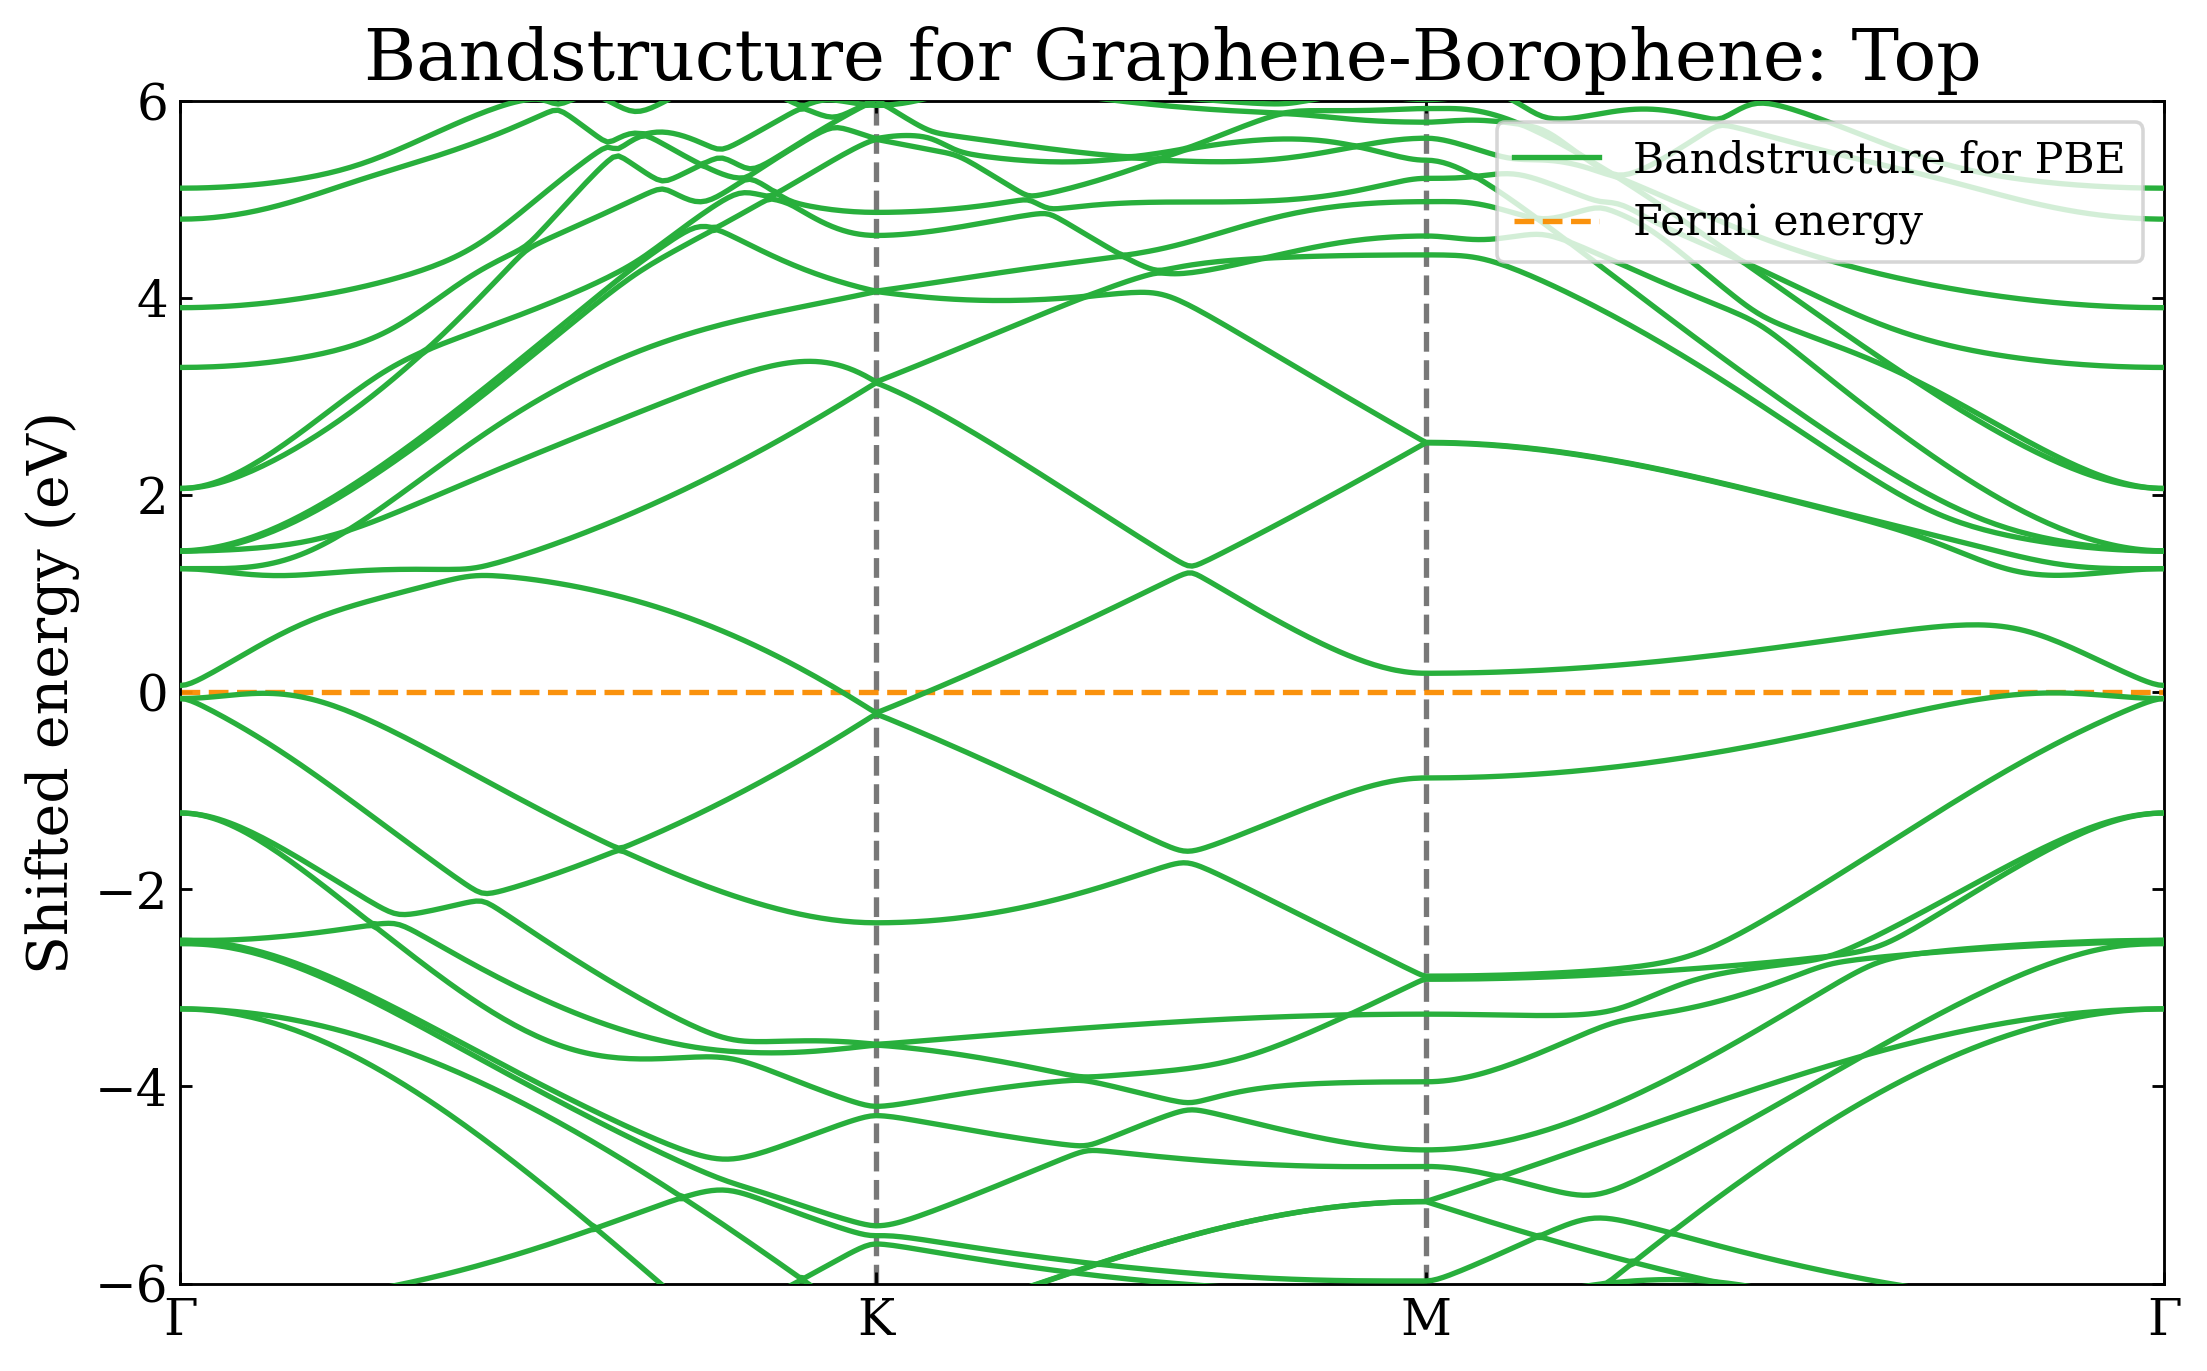

In [7]:
# Graphene-Borophene: Top

bandstructure_list = [["PBE","3_Bandstructure_PBE/F_Graphene-Borophene_Top","green"]]

plot_bandstructure("Graphene-Borophene: Top", 6, "monocolor", bandstructure_list, "upper right")


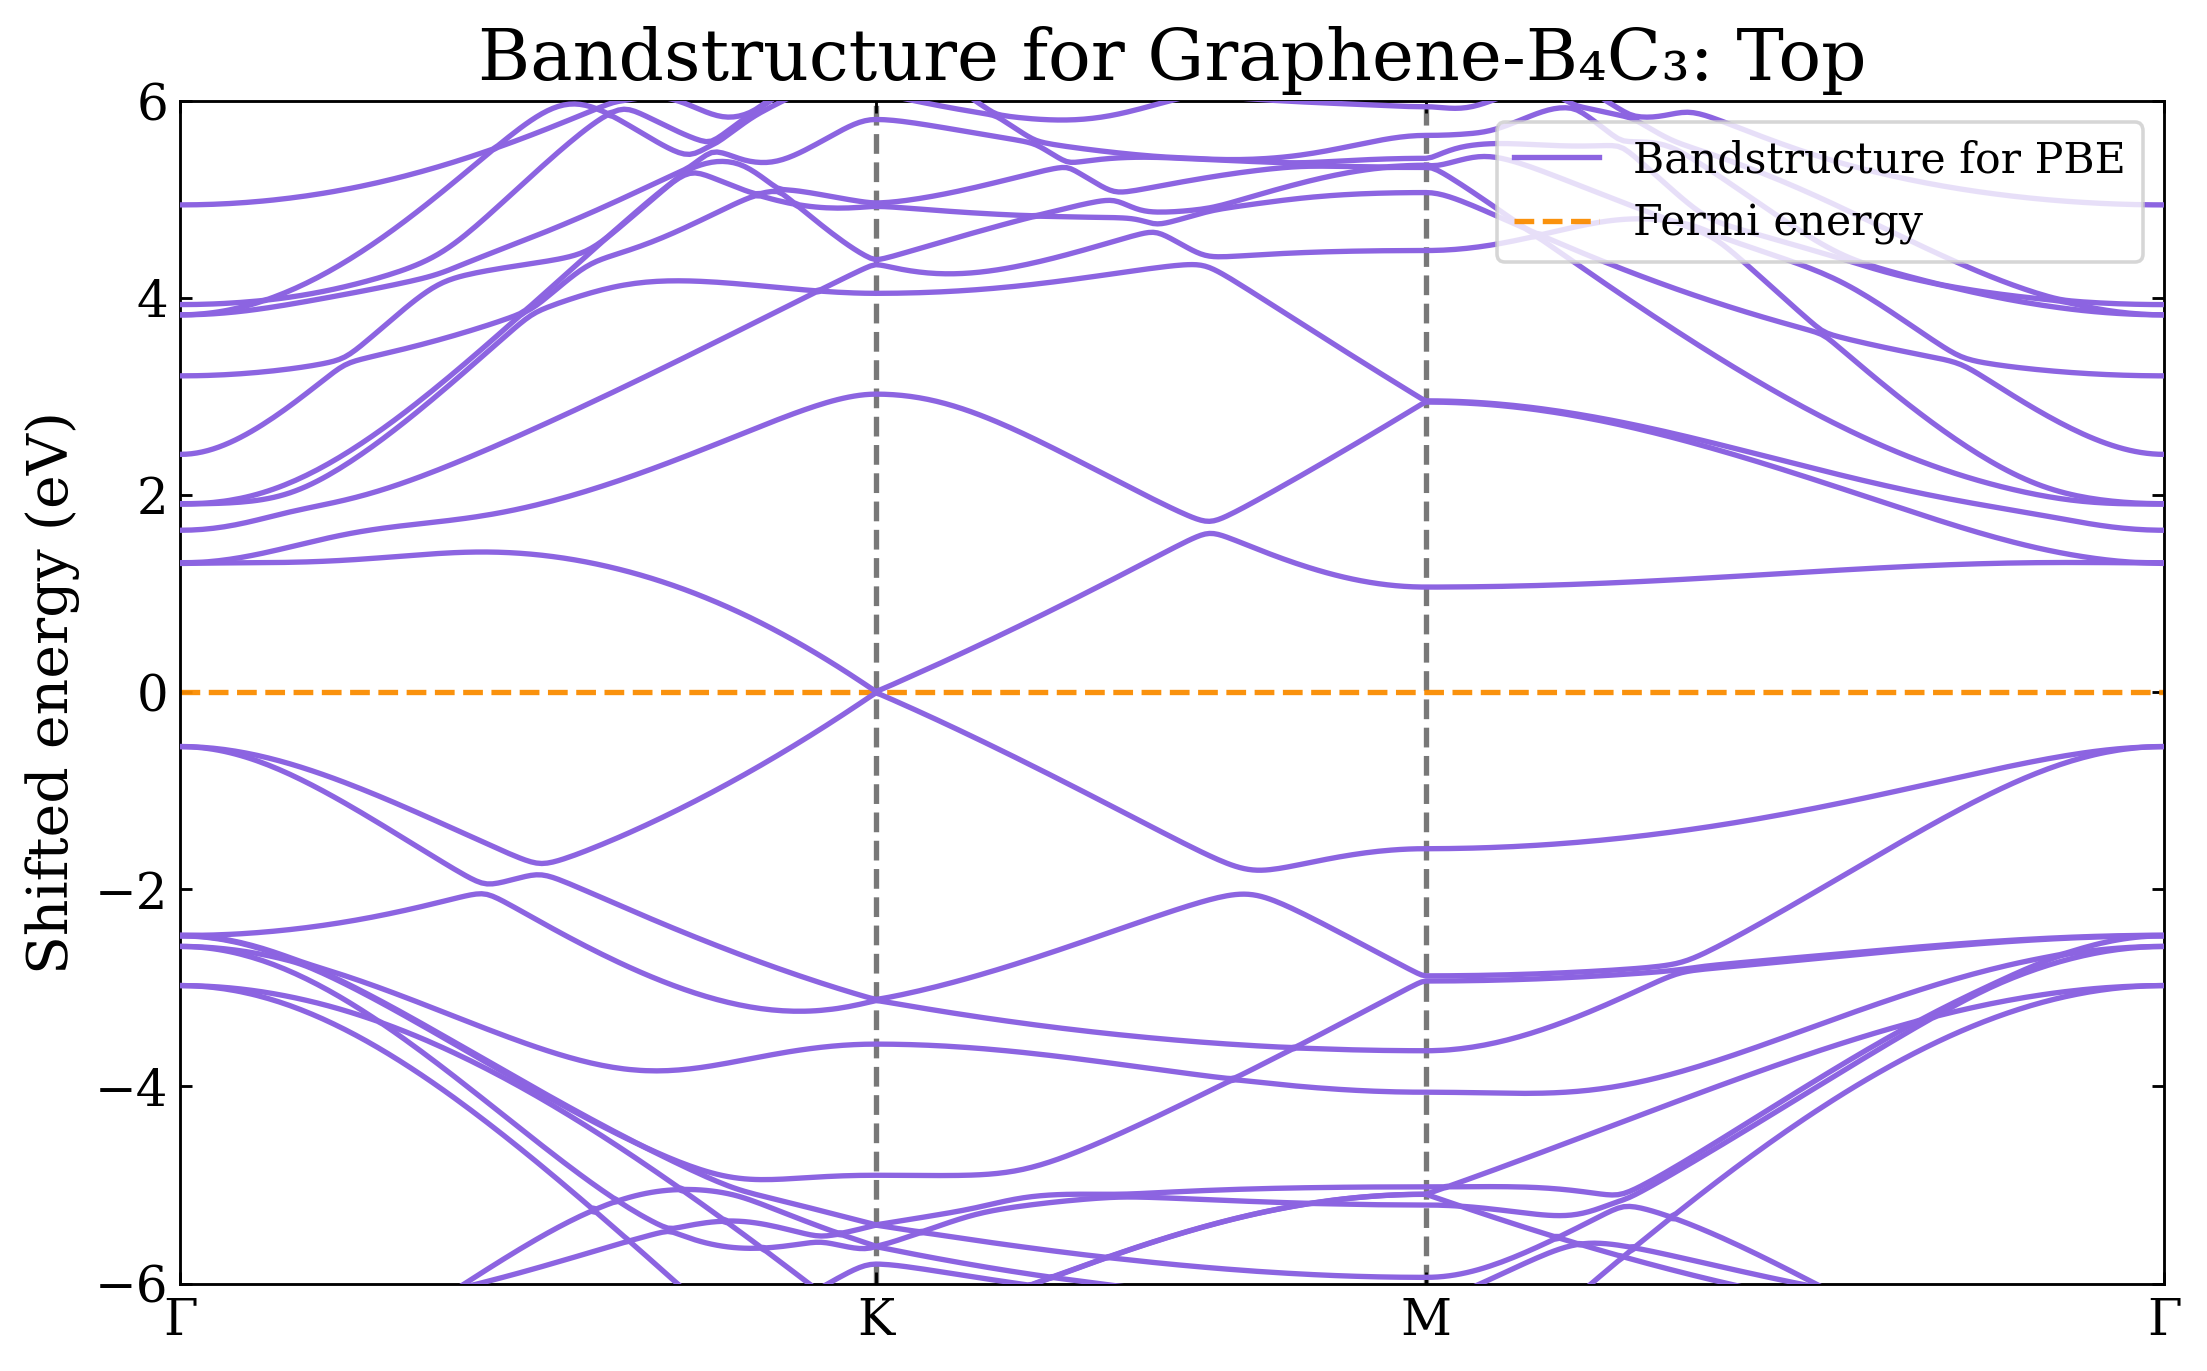

In [8]:
# Graphene-B₄C₃: Top

bandstructure_list = [["PBE","3_Bandstructure_PBE/G_Graphene-B4C3_Top","violet"]]

plot_bandstructure("Graphene-B₄C₃: Top", 6, "monocolor", bandstructure_list, "upper right")
